In [226]:
from pathlib import Path

import sys
# Add src to path for importing local modules
sys.path.insert(0, str(Path("../src").resolve()))

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from trompy import save_figure_atomic

from src.outlier_filter import robust_tail_filter_log_area

mpl.rcParams["figure.dpi"] = 150
mpl.rcParams["font.size"] = 8
mpl.rcParams["font.family"] = "Arial"
mpl.rcParams['savefig.transparent'] = True

SAVEFIGS = True

In [227]:
DATAFOLDER = Path("./data")
METAFILE = Path("./data/fenestrations_metafile.xlsx")
FIGSFOLDER = Path("./figs/paper1/panels")

# Ensure output folder exists for direct saves.
FIGSFOLDER.mkdir(parents=True, exist_ok=True)

# save_figure_atomic stages files under _tmp/<relative output path>;
# ensure that staging path exists when using relative figure folders.
(Path.cwd() / "_tmp" / FIGSFOLDER).mkdir(parents=True, exist_ok=True)

data = pd.read_pickle(DATAFOLDER / "roi_data.pickle")

# Extract the DataFrames
rois_df = data['rois']
summary_df = data['summary']

# load metafile
metadata = pd.read_excel(METAFILE)

print("ROI Data Statistics")
print("=" * 50)
print(f"\nROIs DataFrame:")
print(f"  Rows: {len(rois_df)}")
print(f"  Columns: {len(rois_df.columns)}")
print(f"  Column names: {list(rois_df.columns)}")
print(f"\n  Memory usage: {rois_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print(f"\n\nSummary DataFrame:")
print(f"  Rows: {len(summary_df)}")
print(f"  Columns: {len(summary_df.columns)}")
print(f"  Column names: {list(summary_df.columns)}")
print(f"\n  Memory usage: {summary_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

print("\n" + "=" * 50)
print("\nFirst few rows of ROIs DataFrame:")
print(rois_df.head())

print("\n" + "=" * 50)
print("\nFirst few rows of Summary DataFrame:")
print(summary_df.head())

print("\n" + "=" * 50)
print("\nData types:")
print("\nROIs DataFrame:")
print(rois_df.dtypes)
print("\nSummary DataFrame:")
print(summary_df.dtypes)

ROI Data Statistics

ROIs DataFrame:
  Rows: 234865
  Columns: 33
  Column names: ['id', 'stub', 'roi_id', 'centroid_x', 'centroid_y', 'pixel_count', 'pixel_size', 'area', 'cluster_neighbor_count', 'cluster_neighbor_ids', 'cluster_max_internal_angle_deg', 'cluster_max_angular_gap_deg', 'cluster_is_convex', 'cluster_center_inside_polygon', 'cluster_is_valid', 'cluster_neighbor_distance', 'profile_major', 'profile_minor', 'profile_diag45', 'profile_diag135', 'four_axis_mean', 'major_axis_angle', 'major_axis_extent', 'minor_axis_extent', 'major_axis_length_px', 'minor_axis_length_px', 'step_major', 'step_minor', 'step_diag45', 'step_diag135', 'diameter_area', 'experiment', 'condition']

  Memory usage: 262.44 MB


Summary DataFrame:
  Rows: 548
  Columns: 20
  Column names: ['id', 'stub', 'mean_neighbor_count', 'mean_cluster_neighbor_distance_px', 'mean_cluster_neighbor_distance_nm', 'mean_roi_area_nm2', 'mean_pixel_size_nm_per_px', 'mean_diameter_area_nm', 'mean_diameter_major_nm', 'mean

In [228]:
def get_filtered_control_data(rois_df, summary_df):
    
    rois_df, _ = robust_tail_filter_log_area(rois_df)
    rois_df = rois_df.query("condition == 'control'").reset_index(drop=True)
    summary_df = summary_df.query("condition == 'control'").reset_index(drop=True)
    
    return rois_df, summary_df

rois_df, summary_df = get_filtered_control_data(rois_df, summary_df)

In [229]:
rois_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 59139 entries, 0 to 59138
Data columns (total 34 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              59139 non-null  object 
 1   stub                            59139 non-null  object 
 2   roi_id                          59139 non-null  int64  
 3   centroid_x                      59139 non-null  float64
 4   centroid_y                      59139 non-null  float64
 5   pixel_count                     59139 non-null  int64  
 6   pixel_size                      59139 non-null  float64
 7   area                            59139 non-null  float64
 8   cluster_neighbor_count          45026 non-null  float64
 9   cluster_neighbor_ids            45026 non-null  object 
 10  cluster_max_internal_angle_deg  45026 non-null  float64
 11  cluster_max_angular_gap_deg     45026 non-null  float64
 12  cluster_is_convex               45026 non-n

In [240]:
# setting plotting conventions

def init_diameter_panel():
    f, ax = plt.subplots(figsize=(1.5, 1.2),
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.95, "bottom": 0.37})
    
    return f, ax

circularity_diam_color = "coral"
elliptical_color = "lightcoral"
diameter_color = "steelblue"
circularity_color = "coral"
minor_color = "seagreen"
major_color = "mediumpurple"
neighbor_color = "goldenrod"

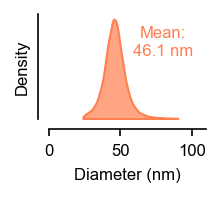

In [241]:
## Panel A: Diameter distribution (circular)

xlims = (0, 110)

f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.diameter_area,
            fill=True, ax=ax, color=circularity_diam_color, alpha=0.7,
            cut=0)

ax.set_xlim(xlims)
ax.set_xlabel("Diameter (nm)")

ax.set_yticks([])

ax.text(80, 0.04, f"Mean:\n{rois_df.diameter_area.mean():.1f} nm", ha="center", color=circularity_diam_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_circular")

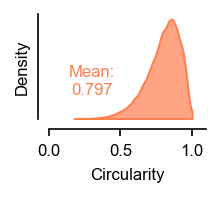

In [248]:
## Panel B: Circularity distribution

rois_df["circularity"] = rois_df.minor_axis_length_px / rois_df.major_axis_length_px


f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.circularity,
            fill=True, ax=ax, color=circularity_color, alpha=0.7,
            cut=0)
ax.set_xlabel("Circularity")
ax.set_xlim(0, 1.1)
ax.set_yticks([])

ax.text(0.3, 0.94, f"Mean:\n{rois_df.circularity.mean():.3f}", ha="center", color=circularity_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "circularity")

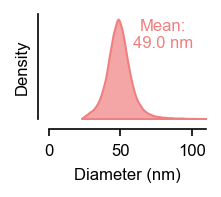

In [243]:
## Panel C: Diameter distribution (elliptical)

# Figure for diameter based on major/minor axis
# Calculate equivalent diameter in px
rois_df['elliptical_diameter'] = np.sqrt(rois_df.major_axis_length_px * rois_df.minor_axis_length_px) 

f, ax = init_diameter_panel()
sns.kdeplot(data=rois_df.elliptical_diameter,
            fill=True, ax=ax, color=elliptical_color, alpha=0.7,
            cut=0)

ax.set_xlabel("Diameter (nm)")
ax.set_xlim(xlims)
ax.set_yticks([])

ax.text(80, 0.04, f"Mean:\n{rois_df.elliptical_diameter.mean():.1f} nm", ha="center", color=elliptical_color)

sns.despine(offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_elliptical")


In [169]:
def get_spacing_factor(rois_df, row, axis):
    
    if axis == "major":
        return (rois_df
                .query("stub == @row.stub")
                .step_major_nm
                .mean()
                )
    elif axis == "minor":
        return (rois_df
                .query("stub == @row.stub")
                .step_minor_nm
                .mean()
                )
    else:
        raise ValueError("Axis must be 'major' or 'minor'")

# per-ROI nm per sample
rois_df["step_major_nm"] = rois_df["step_major"] * rois_df["pixel_size"]
rois_df["step_minor_nm"] = rois_df["step_minor"] * rois_df["pixel_size"]

In [181]:
from src.roi_analysis import estimate_diameter_from_profile
from src.diameter_calcs import _compute_dip_width, _compute_dip_width_derivative

# Get per-stub mean step in nm
step_per_stub = (
    rois_df
    .groupby("stub")[["step_major_nm", "step_minor_nm"]]
    .mean()
    .reset_index()
)

sdf = summary_df.merge(step_per_stub, on="stub", how="left")

method_fns = {
    "p2p":  lambda prof, step_nm, px_size: estimate_diameter_from_profile(
                prof, px_size, sample_step_px=step_nm / px_size),
    "fwhm": lambda prof, step_nm, px_size: _compute_dip_width(prof, step_nm),
    "deriv": lambda prof, step_nm, px_size: _compute_dip_width_derivative(prof, step_nm),
}

rows = []
for _, row in sdf.iterrows():
    pixel_size = row["mean_pixel_size_nm_per_px"]
    entry = {"stub": row.stub}

    for method, fn in method_fns.items():
        diams = {}
        for axis in ("major", "minor"):
            profile = row[f"mean_profile_{axis}_smpls"]
            step_nm = row[f"step_{axis}_nm"]

            if profile is None or not np.isfinite(step_nm) or not np.isfinite(pixel_size):
                diams[axis] = np.nan
                continue

            diams[axis] = fn(np.asarray(profile), step_nm, pixel_size)

        d_maj, d_min = diams["major"], diams["minor"]
        entry[f"diameter_{method}_major_nm"] = d_maj
        entry[f"diameter_{method}_minor_nm"] = d_min
        entry[f"diameter_{method}_nm"] = (
            np.sqrt(d_maj * d_min)
            if np.isfinite(d_maj) and np.isfinite(d_min)
            else np.nan
        )

    rows.append(entry)

profile_diams_df = pd.DataFrame(rows)
print(
    profile_diams_df[
        [
            "diameter_p2p_major_nm", "diameter_p2p_minor_nm", "diameter_p2p_nm",
            "diameter_fwhm_major_nm", "diameter_fwhm_minor_nm", "diameter_fwhm_nm",
            "diameter_deriv_major_nm", "diameter_deriv_minor_nm", "diameter_deriv_nm",
        ]
    ].describe().round(1)
)

       diameter_p2p_major_nm  diameter_p2p_minor_nm  diameter_p2p_nm  \
count                  137.0                  137.0            137.0   
mean                   122.5                  103.1            112.2   
std                     11.2                   14.2             11.1   
min                     99.6                   66.3             86.5   
25%                    113.8                   93.4            103.9   
50%                    121.5                  101.2            111.3   
75%                    130.0                  111.7            119.8   
max                    157.9                  148.6            149.2   

       diameter_fwhm_major_nm  diameter_fwhm_minor_nm  diameter_fwhm_nm  \
count                   137.0                   137.0             137.0   
mean                     58.2                    46.1              51.7   
std                       7.1                     4.9               5.4   
min                      24.8                    22

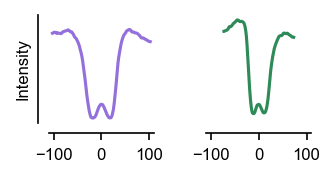

In [184]:
# prep data for profiles plot
row = summary_df.iloc[0]

f, ax = plt.subplots(figsize=(2.5, 1.2), ncols=2, sharey=True,
                         gridspec_kw={"left": 0.25, "right": 0.95, "top": 0.95, "bottom": 0.35,
                                      "wspace": 0.5})

major_profile = row.mean_profile_major_smpls
n = len(major_profile)
x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "major")

ax[0].plot(x_nm, major_profile, color=major_color)
ax[0].set_ylabel("Intensity")
ax[0].set_yticks([])

sns.despine(ax=ax[0], offset=5)

minor_profile = row.mean_profile_minor_smpls
n = len(minor_profile)
x_nm = (np.arange(n) - (n - 1) / 2) * get_spacing_factor(rois_df, row, "minor")

ax[1].plot(x_nm, minor_profile, color=minor_color)

for axis in ax:
    axis.set_xlim(-110, 110)
    
sns.despine(ax=ax[1], offset=5, left=True)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "profiles")

In [185]:
profile_diams_df.columns

Index(['stub', 'diameter_p2p_major_nm', 'diameter_p2p_minor_nm',
       'diameter_p2p_nm', 'diameter_fwhm_major_nm', 'diameter_fwhm_minor_nm',
       'diameter_fwhm_nm', 'diameter_deriv_major_nm',
       'diameter_deriv_minor_nm', 'diameter_deriv_nm'],
      dtype='str')

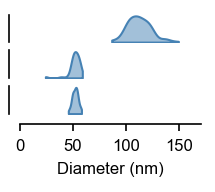

In [205]:
f, ax = plt.subplots(
    3, 1,
    figsize=(1.8, 1.2),
    # sharex=True,
    gridspec_kw={"left": 0.28, "right": 0.95, "top": 0.95, "bottom": 0.4, "hspace": 0.3}
)

kde_specs = [
    ("diameter_p2p_nm", "P2P", diameter_color),
    ("diameter_fwhm_nm", "FWHM", diameter_color),
    ("diameter_deriv_nm", "Derivative", diameter_color),
]

for i, (col, label, color) in enumerate(kde_specs):
    vals = profile_diams_df[col].dropna()
    if len(vals) > 1:
        sns.kdeplot(data=vals, fill=True, ax=ax[i], color=color, alpha=0.5, cut=0)

    ax[i].set_xlim(xlims)
    ax[i].set_yticks([])
    # ax[i].set_ylabel(label, rotation=0, ha="right", va="center", labelpad=12)
    ax[i].set_ylabel("")
    
    if i < 2:
        ax[i].set_xlabel("")

    sns.despine(ax=ax[i], offset=5)

xlims = (0, 170)

for axis in ax[:2]:
    sns.despine(ax=axis, bottom=True)
    axis.set_xticks([])
    axis.set_xlim(xlims)

ax[-1].set_xlabel("Diameter (nm)")
ax[-1].set_xticks([0, 50, 100, 150])
ax[-1].set_xlim(xlims)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_profiles")

In [180]:
profile_diams_df

,stub,diameter_p2p_nm,diameter_fwhm_nm,diameter_deriv_nm
0,PR11_ME_03,111.479302,54.906506,53.218370
1,PR11_ME_04,113.782318,55.555528,52.861228
2,PR11_ME_05,137.742839,54.075576,48.034106
3,PR11_ME_06,94.325198,47.782192,46.549051
4,PR11_ME_07,123.353118,55.172855,53.116643
...,...,...,...,...
132,PR24_ME_03,117.326304,51.146078,48.419387
133,PR24_ME_04,119.990241,50.202396,50.559713
134,PR24_ME_05,135.644676,56.238412,50.559587
135,PR24_ME_06,108.043153,53.515903,50.107104


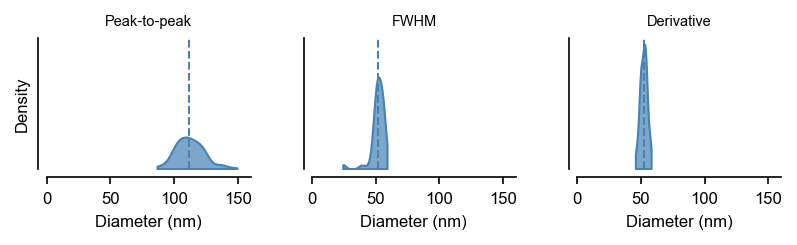

In [179]:
methods = {
    "diameter_p2p_nm":  "Peak-to-peak",
    "diameter_fwhm_nm": "FWHM",
    "diameter_deriv_nm": "Derivative",
}

fig, axes = plt.subplots(
    1, 3,
    figsize=(5.5, 1.5),
    sharey=True,
    gridspec_kw={"left": 0.08, "right": 0.97, "top": 0.88,
                 "bottom": 0.3, "wspace": 0.3},
)

xlims = (0, 160)

for ax, (col, label) in zip(axes, methods.items()):
    vals = profile_diams_df[col].dropna()
    if len(vals) > 1:
        sns.kdeplot(vals, ax=ax, fill=True, color="steelblue", alpha=0.7, cut=0)
    ax.axvline(vals.median(), color="steelblue", lw=1, ls="--")
    ax.set_xlim(xlims)
    ax.set_yticks([])
    ax.set_title(label, fontsize=7)
    ax.set_xlabel("Diameter (nm)")
    sns.despine(ax=ax, offset=4)

if SAVEFIGS:
    save_figure_atomic(fig, FIGSFOLDER / "diameter_profile_methods")

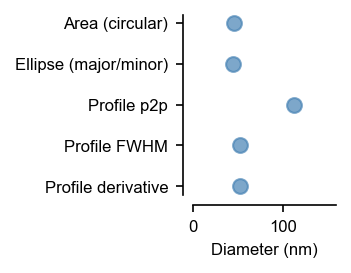

In [225]:
# Mean diameter comparing five measurement methods

# ROI-level elliptical diameter in nm from raw ROI extents (not profile path length)
major_diameter_nm = 2.0 * rois_df["major_axis_extent"] * rois_df["pixel_size"]
minor_diameter_nm = 2.0 * rois_df["minor_axis_extent"] * rois_df["pixel_size"]
rois_df["diameter_elliptical_nm"] = np.sqrt(major_diameter_nm * minor_diameter_nm)

diameter_boxplot_df = pd.concat(
    [
        pd.DataFrame({
            "method": "Area (circular)",
            "diameter_nm": rois_df["diameter_area"],
        }),
        pd.DataFrame({
            "method": "Ellipse (major/minor)",
            "diameter_nm": rois_df["diameter_elliptical_nm"],
        }),
        pd.DataFrame({
            "method": "Profile p2p",
            "diameter_nm": profile_diams_df["diameter_p2p_nm"],
        }),
        pd.DataFrame({
            "method": "Profile FWHM",
            "diameter_nm": profile_diams_df["diameter_fwhm_nm"],
        }),
        pd.DataFrame({
            "method": "Profile derivative",
            "diameter_nm": profile_diams_df["diameter_deriv_nm"],
        }),
    ],
    ignore_index=True,
).dropna(subset=["diameter_nm"])

method_order = [
    "Profile derivative",
    "Profile FWHM",
    "Profile p2p",
    "Ellipse (major/minor)",
    "Area (circular)",
]

# Compute mean for each method
mean_data = []
for method in method_order:
    data = diameter_boxplot_df[diameter_boxplot_df["method"] == method]["diameter_nm"].values
    mean = np.mean(data)
    mean_data.append({"method": method, "mean": mean})

mean_df = pd.DataFrame(mean_data)

f, ax = plt.subplots(
    figsize=(1.8, 1.5),
    gridspec_kw={"left": 0.45, "right": 0.98, "top": 0.95, "bottom": 0.15}
)

# Plot mean markers only
y_pos = np.arange(len(method_order))
ax.scatter(
    mean_df["mean"],
    y_pos,
    color="steelblue",
    s=50,
    alpha=0.7,
    zorder=3,
)

ax.set_yticks(y_pos)
ax.set_yticklabels(method_order)
ax.set_xlabel("Diameter (nm)")
ax.set_xlim(0, 160)

sns.despine(ax=ax, offset=5)

if SAVEFIGS:
    save_figure_atomic(f, FIGSFOLDER / "diameter_boxplot_5methods")